### This notebook requires a GPU runtime to run.
### Please select the menu option "Runtime" -> "Change runtime type", select "Hardware Accelerator" -> "GPU" and click "SAVE"

----------------------------------------------------------------------

# HiFi GAN

*Author: NVIDIA*

**The HiFi GAN model for generating waveforms from mel spectrograms**

<img src="https://pytorch.org/assets/images/hifigan_model.png" alt="alt" width="50%"/>



### Model Description
This notebook demonstrates a PyTorch implementation of the HiFi-GAN model described in the paper: [HiFi-GAN: Generative Adversarial Networks for Efficient and High Fidelity Speech Synthesis](https://arxiv.org/abs/2010.05646).
The HiFi-GAN model implements a spectrogram inversion model that allows to synthesize speech waveforms from mel-spectrograms. It follows the generative adversarial network (GAN) paradigm, and is composed of a generator and a discriminator. After training, the generator is used for synthesis, and the discriminator is discarded.

Our implementation is based on the one [published by the authors of the paper](https://github.com/jik876/hifi-gan). We modify the original hyperparameters and provide an alternative training recipe, which enables training on larger batches and faster convergence. HiFi-GAN is trained on a publicly available [LJ Speech dataset](https://keithito.com/LJ-Speech-Dataset/). The <a href="audio/">samples</a> demonstrate speech synthesized with our publicly available FastPitch and HiFi-GAN checkpoints.

#### Model architecture

![HiFiGAN Architecture](https://raw.githubusercontent.com/NVIDIA/DeepLearningExamples/master/PyTorch/SpeechSynthesis/HiFiGAN/img/hifigan_model.png)

### Example
In the example below:

- pretrained FastPitch and HiFiGAN models are loaded from torch.hub
- given tensor representation of an input text ("Say this smoothly to prove you are not a robot."), FastPitch generates mel spectrogram
- HiFiGAN generates sound given the mel spectrogram
- the output sound is saved in an 'audio.wav' file

To run the example you need some extra python packages installed. These are needed for preprocessing of text and audio, as well as for display and input/output handling. Finally, for better performance of FastPitch model, we download the CMU pronounciation dictionary.

In [1]:
%%bash
pip install numpy scipy librosa unidecode inflect librosa matplotlib==3.6.3
apt-get update
apt-get install -y libsndfile1 wget
wget https://raw.githubusercontent.com/NVIDIA/NeMo/263a30be71e859cee330e5925332009da3e5efbc/scripts/tts_dataset_files/heteronyms-052722 -qO heteronyms
wget https://raw.githubusercontent.com/NVIDIA/NeMo/263a30be71e859cee330e5925332009da3e5efbc/scripts/tts_dataset_files/cmudict-0.7b_nv22.08 -qO cmudict-0.7b

error: externally-managed-environment

× This environment is externally managed
╰─> To install Python packages system-wide, try apt install
    python3-xyz, where xyz is the package you are trying to
    install.
    
    If you wish to install a non-Debian-packaged Python package,
    create a virtual environment using python3 -m venv path/to/venv.
    Then use path/to/venv/bin/python and path/to/venv/bin/pip. Make
    sure you have python3-full installed.
    
    If you wish to install a non-Debian packaged Python application,
    it may be easiest to use pipx install xyz, which will manage a
    virtual environment for you. Make sure you have pipx installed.
    
    See /usr/share/doc/python3.12/README.venv for more information.

note: If you believe this is a mistake, please contact your Python installation or OS distribution provider. You can override this, at the risk of breaking your Python installation or OS, by passing --break-system-packages.
hint: See PEP 668 for the detai

Get:1 http://security.ubuntu.com/ubuntu noble-security InRelease [126 kB]
Hit:2 http://archive.ubuntu.com/ubuntu noble InRelease
Get:3 http://archive.ubuntu.com/ubuntu noble-updates InRelease [126 kB]
Get:4 http://security.ubuntu.com/ubuntu noble-security/main amd64 Components [21.5 kB]
Get:5 http://security.ubuntu.com/ubuntu noble-security/universe amd64 Components [52.3 kB]
Get:6 http://security.ubuntu.com/ubuntu noble-security/restricted amd64 Components [212 B]
Get:7 http://security.ubuntu.com/ubuntu noble-security/multiverse amd64 Components [208 B]
Get:8 http://archive.ubuntu.com/ubuntu noble-backports InRelease [126 kB]
Get:9 http://archive.ubuntu.com/ubuntu noble-updates/main amd64 Components [161 kB]
Get:10 http://archive.ubuntu.com/ubuntu noble-updates/universe amd64 Components [376 kB]
Get:11 http://archive.ubuntu.com/ubuntu noble-updates/restricted amd64 Components [212 B]
Get:12 http://archive.ubuntu.com/ubuntu noble-updates/multiverse amd64 Components [940 B]
Get:13 http:

In [2]:
# 安装 Python 包
!pip install numpy scipy librosa unidecode inflect matplotlib==3.6.3

# 下载两个文件
import urllib.request

# heteronyms
urllib.request.urlretrieve(
    "https://raw.githubusercontent.com/NVIDIA/NeMo/263a30be71e859cee330e5925332009da3e5efbc/scripts/tts_dataset_files/heteronyms-052722",
    "heteronyms"
)

# cmudict
urllib.request.urlretrieve(
    "https://raw.githubusercontent.com/NVIDIA/NeMo/263a30be71e859cee330e5925332009da3e5efbc/scripts/tts_dataset_files/cmudict-0.7b_nv22.08",
    "cmudict-0.7b"
)


('cmudict-0.7b', <http.client.HTTPMessage at 0x2de03498b90>)

In [3]:
import torch
import matplotlib.pyplot as plt
from IPython.display import Audio
import warnings
warnings.filterwarnings('ignore')

device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
print(f'Using {device} for inference')

Using cuda for inference


Download and setup FastPitch generator model.

In [4]:
fastpitch, generator_train_setup = torch.hub.load('NVIDIA/DeepLearningExamples:torchhub', 'nvidia_fastpitch')

Using cache found in C:\Users\wuann/.cache\torch\hub\NVIDIA_DeepLearningExamples_torchhub


Download and setup vocoder and denoiser models.

In [5]:
hifigan, vocoder_train_setup, denoiser = torch.hub.load('NVIDIA/DeepLearningExamples:torchhub', 'nvidia_hifigan')

Using cache found in C:\Users\wuann/.cache\torch\hub\NVIDIA_DeepLearningExamples_torchhub


HiFi-GAN: Removing weight norm.


Verify that generator and vocoder models agree on input parameters.

In [6]:
CHECKPOINT_SPECIFIC_ARGS = [
    'sampling_rate', 'hop_length', 'win_length', 'p_arpabet', 'text_cleaners',
    'symbol_set', 'max_wav_value', 'prepend_space_to_text',
    'append_space_to_text']

for k in CHECKPOINT_SPECIFIC_ARGS:

    v1 = generator_train_setup.get(k, None)
    v2 = vocoder_train_setup.get(k, None)

    assert v1 is None or v2 is None or v1 == v2, \
        f'{k} mismatch in spectrogram generator and vocoder'

Put all models on available device.

In [7]:
fastpitch.to(device)
hifigan.to(device)
denoiser.to(device)

Denoiser(
  (stft): STFT()
)

Load text processor.

In [8]:
tp = torch.hub.load('NVIDIA/DeepLearningExamples:torchhub', 'nvidia_textprocessing_utils', cmudict_path="cmudict-0.7b", heteronyms_path="heteronyms")

Using cache found in C:\Users\wuann/.cache\torch\hub\NVIDIA_DeepLearningExamples_torchhub


Set the text to be synthetized, prepare input and set additional generation parameters.

In [9]:
text = "The examination and testimony of the experts enabled the Commission to conclude that five shots may have been fired"

In [10]:
batches = tp.prepare_input_sequence([text], batch_size=1)

the {IH0 G Z AE2 M AH0 N EY1 SH AH0 N} and {T EH1 S T IH0 M OW2 N IY0} of the {EH1 K S P ER0 T S} enabled the {K AH0 M IH1 SH AH0 N} to {K AH0 N K L UW1 D} that {F AY1 V} {SH AA1 T S} {M EY1} {HH AE1 V} been {F AY1 ER0 D}


In [11]:
gen_kw = {'pace': 1.0,
          'speaker': 0,
          'pitch_tgt': None,
          'pitch_transform': None}
denoising_strength = 0.005

In [17]:
for batch in batches:
    with torch.no_grad():
        mel, mel_lens, *_ = fastpitch(batch['text'].to(device), **gen_kw)
        audios = hifigan(mel).float()
        audios = denoiser(audios.squeeze(1), denoising_strength)
        audios = audios.squeeze(1) * vocoder_train_setup['max_wav_value']


In [18]:
mel

tensor([[[-7.3493, -6.6866, -6.1811,  ..., -7.2470, -7.2938, -6.7503],
         [-6.9514, -6.2677, -5.6328,  ..., -6.7192, -6.7236, -6.4897],
         [-6.4540, -5.8268, -5.1985,  ..., -6.2280, -6.1897, -6.1993],
         ...,
         [-6.0104, -5.7195, -5.0778,  ..., -9.0325, -9.0720, -8.8990],
         [-5.6357, -5.3359, -4.9570,  ..., -9.1835, -9.2097, -8.9916],
         [-5.6845, -5.3849, -5.1118,  ..., -9.3175, -9.3145, -9.0487]]],
       device='cuda:0')

In [100]:
import torch
import torchaudio
from audioseal import AudioSeal

device = 'cuda' if torch.cuda.is_available() else 'cpu'
model = AudioSeal.load_generator("audioseal_wm_16bits").to(device)
detector = AudioSeal.load_detector(("audioseal_detector_16bits")).to(device)

In [101]:
import os
import torch
import soundfile as sf
from tqdm import tqdm

# 创建保存目录
os.makedirs("hifi-gan", exist_ok=True)

import random
def generate_random_sentence():
    subjects = ["The cat", "A robot", "My friend", "The teacher", "This app"]
    verbs = ["is running", "is talking", "eats pizza", "writes code", "plays music"]
    endings = ["in the park.", "with a smile.", "every day.", "like a pro.", "on Mars."]
    return f"{random.choice(subjects)} {random.choice(verbs)} {random.choice(endings)}"

scores_gan = []
# 主循环
with open("metadata.csv", "w", encoding="utf-8") as f:
    for i in tqdm(range(100), disable=True):
        uid = f"{i:05d}"
        text = generate_random_sentence()

        try:
            with torch.no_grad():

                tokens = tp.prepare_input_sequence([text], batch_size=1)
                mel, mel_lens, *_ =  fastpitch(tokens[0]['text'].to(device), **gen_kw)
                audio = hifigan(mel).float()
                audio = denoiser(audio.squeeze(0), denoising_strength)
                audio = audio.squeeze(0) * vocoder_train_setup['max_wav_value']
                # audio = audio.squeeze(0)
                score, message = detector.detect_watermark(audio.unsqueeze(0).to(device), sample_rate = 22050, message_threshold=0.5)
                scores_gan.append(score)

            audio = audio / max(abs(audio.max()), abs(audio.min()) + 1e-9)  # 归一化处理 如果进行归一化处理，保存到本地的音频将不会检测到水印
            # 保存音频
            sf.write(f"hifi-gan/{uid}.wav", audio[0].cpu().numpy(), samplerate=22050, subtype= "FLOAT") #默认的类型是16比特 Int，如果不加subtype = “FLoat”，保存到本地的音频也不会检测到水印

            # 保存文本
            f.write(f"{uid}|{text}\n")

            # 清理显存（推荐）
            torch.cuda.empty_cache()

        except Exception as e:
            print(f"[ERROR] Failed at {uid}: {e}")

the {T IY1 CH ER0} {P L EY1 Z} {M Y UW1 Z IH0 K} {L AY1 K} a {P R OW1}.
a robot is {R AH1 N IH0 NG} in the {P AA1 R K}.
{M AY1} {F R EH1 N D} {P L EY1 Z} {M Y UW1 Z IH0 K} {L AY1 K} a {P R OW1}.
the {K AE1 T} {P L EY1 Z} {M Y UW1 Z IH0 K} {L AY1 K} a {P R OW1}.
the {T IY1 CH ER0} {IY1 T S} {P IY1 T S AH0} on {M AA1 R Z}.
this {AE1 P} is {R AH1 N IH0 NG} every {D EY1}.
the {T IY1 CH ER0} {IY1 T S} {P IY1 T S AH0} on {M AA1 R Z}.
a robot {R AY1 T S} {K OW1 D} {L AY1 K} a {P R OW1}.
this {AE1 P} {R AY1 T S} {K OW1 D} with a {S M AY1 L}.
the {K AE1 T} {IY1 T S} {P IY1 T S AH0} on {M AA1 R Z}.
this {AE1 P} {IY1 T S} {P IY1 T S AH0} every {D EY1}.
the {T IY1 CH ER0} {IY1 T S} {P IY1 T S AH0} in the {P AA1 R K}.
{M AY1} {F R EH1 N D} {P L EY1 Z} {M Y UW1 Z IH0 K} every {D EY1}.
the {T IY1 CH ER0} {R AY1 T S} {K OW1 D} with a {S M AY1 L}.
a robot {P L EY1 Z} {M Y UW1 Z IH0 K} with a {S M AY1 L}.
a robot {IY1 T S} {P IY1 T S AH0} on {M AA1 R Z}.
the {K AE1 T} {IY1 T S} {P IY1 T S AH0} in the {P

In [102]:
import numpy as np
np.mean(scores_gan)

np.float64(0.861550732254982)

In [103]:
import os
from notebook import play_audio, plot_waveform_and_specgram, plot_waveform_and_melspec
base_path = r'D:\programs\wm\examples\hifi-gan'

audio_files = []

for fname in os.listdir(base_path):
    if fname.endswith('.wav'):
        audio_files.append(os.path.join(base_path, fname))


print(f"analysis completed. There are {len(audio_files)} audios in total")

analysis completed. There are 100 audios in total


In [104]:
Audio(audio[0].cpu().numpy(), rate = 22050)
score, message = detector.detect_watermark(audio.unsqueeze(0), sample_rate = 22050, message_threshold=0.5)
print(score)

0.0


In [105]:
waveform, sr = torchaudio.load(audio_files[-1])
waveform = waveform.to(device)
score, message = detector.detect_watermark(waveform.unsqueeze(0), sample_rate = 22050, message_threshold=0.5)
print(score)

0.0


In [106]:
print(audio.shape, waveform.shape)
mse = torch.mean((audio - waveform) ** 2)
print("MSE:", mse.item())
diff = 0
for i, tensor in enumerate(audio[0]):
    if audio[0][i] != waveform[0][i]:
        diff += 1
print(diff)


torch.Size([1, 44288]) torch.Size([1, 44288])
MSE: 0.0
0


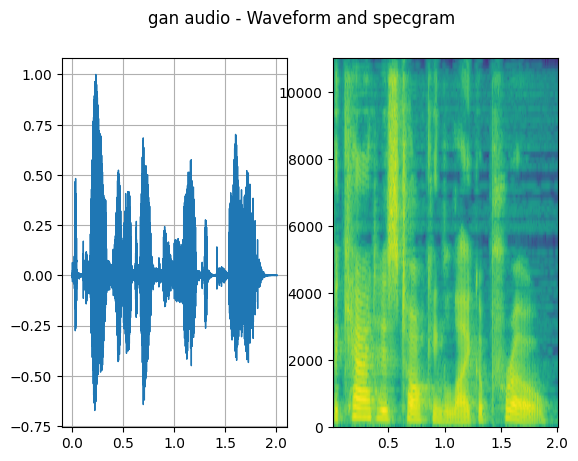

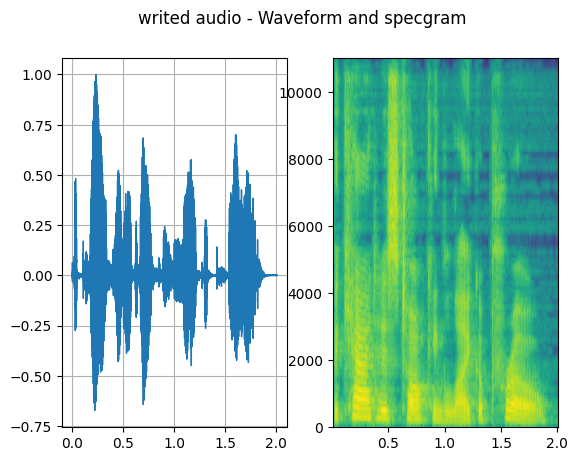

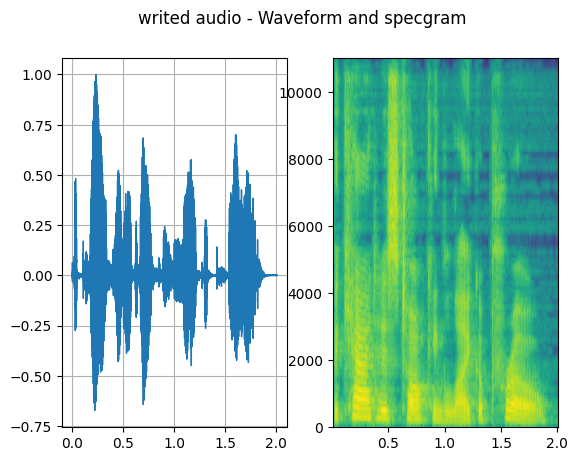

In [107]:
plot_waveform_and_specgram(audio, sr, title="gan audio")
plot_waveform_and_specgram(waveform, sr, title="writed audio")
#对waveform进行归一化处理
waveform_nor = waveform / max(abs(waveform.max()), abs(waveform.min()) + 1e-9)
plot_waveform_and_specgram(waveform_nor, sr, title="writed audio")

In [108]:
score, message = detector.detect_watermark(audio.unsqueeze(0), sample_rate = 22050, message_threshold=0.5)
print(score)
score, message = detector.detect_watermark(waveform.unsqueeze(0), sample_rate = 22050, message_threshold=0.5)
print(score)
score, message = detector.detect_watermark(waveform_nor.unsqueeze(0), sample_rate = 22050, message_threshold=0.5)
print(score)

0.0
0.0
0.0


In [109]:
import torch
import torchaudio
from audioseal import AudioSeal

device = 'cuda' if torch.cuda.is_available() else 'cpu'
model = AudioSeal.load_generator("audioseal_wm_16bits").to(device)
detector = AudioSeal.load_detector(("audioseal_detector_16bits")).to(device)

def get_score(filepath):
    waveform, sr = torchaudio.load(filepath)

    with torch.no_grad():
        score, message = detector.detect_watermark(waveform.unsqueeze(0).to(device), sample_rate = sr, message_threshold=0.5)
    return float(score)

In [110]:
scores = []
for i, path in enumerate(audio_files):
    score = get_score(path)
    scores.append(score)
    if i % 100 == 0:
        print(f"Processed {i}/{len(audio_files)}")

Processed 0/100


In [111]:
from sklearn.metrics import accuracy_score, confusion_matrix, roc_auc_score, roc_curve

threshold = 0.5
preds = [1 if s > threshold else 0 for s in scores]

acc = accuracy_score([0] * 100, preds)

print(f"\n🎯 评估结果（阈值 = {threshold}）")
print(f"不带水印音频的检测Accuracy: {acc:.3f}")
print(np.mean(scores))


🎯 评估结果（阈值 = 0.5）
不带水印音频的检测Accuracy: 1.000
0.0


embed watermark into the original audios

In [114]:
def embed_watermark(filepath):
    waveform, sr = torchaudio.load(filepath)
    waveform = waveform.unsqueeze(0).to(device)
    with torch.no_grad():
        watermark = model.get_watermark(waveform, sample_rate=sr)
        # 对齐 waveform 和 watermark 的长度（取最短）
        min_len = min(waveform.shape[-1], watermark.shape[-1])
        waveform = waveform[..., :min_len]
        watermark = watermark[..., :min_len]
        watermarked_audio = waveform + watermark
        # Alternatively, you can also call forward() function directly with different tune-down / tune-up rate
        watermarked_audio = model(waveform, sample_rate=sr, alpha=1)
        return watermarked_audio

In [115]:
# 创建保存目录
os.makedirs("hifi-gan-watermarked", exist_ok=True)
for i, path in enumerate(audio_files):
    uid = f"{i:05d}"
    # 保存音频
    watermarked_audio = embed_watermark(path)
    sf.write(f"hifi-gan-watermarked/{uid}.wav", watermarked_audio[0][0].cpu().numpy(), samplerate=22050, subtype= "FLOAT")

    # 清理显存（推荐）
    torch.cuda.empty_cache()

In [116]:
import os
from notebook import play_audio, plot_waveform_and_specgram, plot_waveform_and_melspec
base_path = r'D:\programs\wm\examples\hifi-gan-watermarked'

watermarked_audio_files = []

for fname in os.listdir(base_path):
    if fname.endswith('.wav'):
        watermarked_audio_files.append(os.path.join(base_path, fname))


print(f"analysis completed. There are {len(watermarked_audio_files)} audios in total")

analysis completed. There are 100 audios in total


In [117]:
scores = []
for i, path in enumerate(watermarked_audio_files):
    score = get_score(path)
    scores.append(score)
    if i % 100 == 0:
        print(f"Processed {i}/{len(watermarked_audio_files)}")

Processed 0/100


In [120]:
from sklearn.metrics import accuracy_score, confusion_matrix, roc_auc_score, roc_curve

threshold = 0.5
preds = [1 if s > threshold else 0 for s in scores]

acc = accuracy_score([1] * 100, preds)

print(f"\n🎯 评估结果（阈值 = {threshold}）")
print(f"带水印音频的检测Accuracy: {acc:.3f}")
print(np.mean(scores))


🎯 评估结果（阈值 = 0.5）
带水印音频的检测Accuracy: 1.000
0.9999786376953125
